(mmm_endogenous_budget_scenarios)=
# When Does the Budget Model Help? Three Endogenous-Spend Scenarios

{ref}`mmm_endogenous_budget` introduced {class}`~pymc_marketing.mmm.budget_model.BudgetModelEffect` on one data-generating process: planners set budgets from an unrecorded forecast of demand. That process is close to the best case for a control function, because the budget surprise is roughly "demand shock plus noise".

Budgets depend on demand in other ways that are just as common in marketing. This notebook shows three of them:

| Scenario | How TV spend is set | Bias in a plain MMM | Expected $\gamma_{TV}$ |
|---|---|---|---|
| Target chasing | Reacts to last week's sales gap against plan | Understates TV | Negative |
| Search | Follows demand mechanically, up to a weekly cap | Overstates TV | Positive |
| Observed drivers only | Follows demand only through recorded controls | None | Zero |

The third scenario is a negative control. Spend moves with demand, but only through variables the MMM already controls for, so there is nothing to correct and a good diagnostic should say so.

Each market comes from {func}`~pymc_marketing.mmm.synthetic_data.simulate_endogenous_spend_market`, which also returns the TV experiment (as a design for the budget model and as a lift-test summary) and the answer key. For each scenario we simulate one market and compare three fits: a plain MMM, a plain MMM calibrated with a lift likelihood, and an MMM with the budget model and the experiment's design. One market is one draw, so these are illustrations of where the correction matters rather than a simulation study; {ref}`mmm_endogenous_budget` replicates the forecast scenario across markets.

## Prepare Notebook

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pymc_marketing.mmm import (
    MMM,
    BudgetModelEffect,
    GeometricAdstock,
    MichaelisMentenSaturation,
)
from pymc_marketing.mmm.synthetic_data import simulate_endogenous_spend_market

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

plt.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100

%config InlineBackend.figure_format = "retina"

In [2]:
SEED = 11
sample_kwargs = {
    "draws": 500,
    "tune": 1_000,
    "chains": 2,
    "target_accept": 0.95,
    "progressbar": False,
}
FIT_LABELS = {
    "plain": "Plain MMM",
    "lift": "Plain MMM + lift likelihood",
    "budget": "Budget model + design",
}
FIT_COLORS = {"plain": "C0", "lift": "C1", "budget": "C2"}

All fits share one outcome model: geometric adstock and Michaelis-Menten saturation for TV and Digital, the two standardised macro controls, and annual Fourier seasonality. The quantity of interest is TV's marginal return at its typical spend level.

- The plain MMM sees the whole series, experiment weeks included.
- The lift-likelihood fit sees the pre-experiment history plus the experiment's lift summary, so the experiment is not counted twice. It therefore also forgoes the twelve follow-up weeks, so part of its gap to the other fits is sample size.
- The budget model sees the whole series plus the experiment's design, and no lift likelihood. It uses one lagged surprise (`surprise_lags=1`), as in {ref}`mmm_endogenous_budget`.

In [3]:
def make_mmm() -> MMM:
    return MMM(
        date_column="date",
        channel_columns=["tv", "digital"],
        control_columns=["inflation", "unemployment"],
        target_column="y",
        yearly_seasonality=4,
        adstock=GeometricAdstock(l_max=8),
        saturation=MichaelisMentenSaturation(),
    )


def tv_marginal_return(mmm: MMM, x: float) -> np.ndarray:
    posterior = mmm.idata.posterior
    lam = posterior["saturation_lam"].sel(channel="tv") * float(
        mmm.scalers["_channel"].sel(channel="tv")
    )
    beta = posterior["saturation_alpha"].sel(channel="tv") * float(
        mmm.scalers["_target"]
    )
    return (beta * lam / (lam + x) ** 2).to_numpy().ravel()


def fit_market(market) -> tuple[pd.DataFrame, dict, pd.DataFrame]:
    X, y = market.data.drop(columns="y"), market.data["y"]
    n_hist = market.n_history

    plain = make_mmm()
    plain.fit(X, y, random_seed=SEED, **sample_kwargs)

    calibrated = make_mmm()
    calibrated.build_model(X.iloc[:n_hist], y.iloc[:n_hist])
    calibrated.add_lift_test_measurements(market.lift_test)
    calibrated.fit(X.iloc[:n_hist], y.iloc[:n_hist], random_seed=SEED, **sample_kwargs)

    budget_effect = BudgetModelEffect(design=market.design, surprise_lags=1)
    budget = make_mmm().add_mu_effect(budget_effect)
    budget.fit(X, y, random_seed=SEED, **sample_kwargs)

    fits = {"plain": plain, "lift": calibrated, "budget": budget}
    draws = {
        name: tv_marginal_return(mmm, market.operating_point)
        for name, mmm in fits.items()
    }
    truth = market.true_marginal_return
    table = pd.DataFrame(
        {
            FIT_LABELS[name]: {
                "mean": values.mean(),
                "3%": np.quantile(values, 0.03),
                "97%": np.quantile(values, 0.97),
                "divergences": int(fits[name].idata.sample_stats["diverging"].sum()),
            }
            for name, values in draws.items()
        }
    ).T.assign(truth=truth)
    return table, draws, budget_effect.exogeneity_summary(budget)

In [4]:
def plot_mechanism(market, title: str) -> None:
    history = market.data.iloc[: market.n_history]
    spend = history["tv"]
    shock = market.demand_shock[: market.n_history]
    _, ax = plt.subplots(figsize=(12, 4))
    ax.plot(
        history["date"],
        (spend - spend.mean()) / spend.std(),
        color="C0",
        label="TV spend (standardised)",
    )
    ax.plot(
        history["date"],
        (shock - shock.mean()) / shock.std(),
        color="gray",
        label="Unrecorded demand shock (standardised)",
    )
    ax.set(title=f"{title}: correlation {np.corrcoef(spend, shock)[0, 1]:.2f}")
    ax.legend(loc="upper left")


def plot_intervals(draws: dict, truth: float, title: str) -> None:
    _, ax = plt.subplots(figsize=(12, 3))
    for k, (name, values) in enumerate(draws.items()):
        lower, upper = np.quantile(values, [0.03, 0.97])
        ax.errorbar(
            values.mean(),
            k,
            xerr=[[values.mean() - lower], [upper - values.mean()]],
            fmt="o",
            color=FIT_COLORS[name],
            capsize=4,
        )
    ax.axvline(truth, color="black", linestyle="--", label="True value")
    ax.set_yticks(range(len(draws)), [FIT_LABELS[name] for name in draws])
    ax.set(xlabel="TV marginal return (mean and 94% interval)", title=title)
    ax.legend(loc="lower right")

## Scenario 1: Budgets That Chase Targets

Many teams steer spend by results. When last week's sales came in below plan they spend more, and when sales ran ahead they pull back:

$$
\text{TV}_t = 5 - 0.15\,(y_{t-1} - \text{plan}_{t-1}) + \text{noise}_t .
$$

The plan covers the predictable part of demand, so the gap is driven by last week's demand shock. Because the shock is persistent, it also moves this week's sales. Spend is high when demand is weak, so a plain MMM *understates* TV, the opposite of the forecast scenario. This checks whether the diagnostic recovers the sign, rather than merely detecting an association between spend and sales.

The experiment cuts TV by 1.5 per week, relative to what the rule would have chosen, for four weeks. The rule keeps reacting during the test, so the realised change is smaller than the design; the lift-test summary records the realised change.

This scenario also has a trap. Last week's sales are recorded, so it is tempting to pass them to the budget model as one of its `instruments`. An instrument enters the spend equation but not the sales equation, so it must be unrelated to this week's sales error. Lagged sales are not: they carry the same persistent shock. Leaving them out keeps that shock in the budget surprise, where the control function can absorb it.

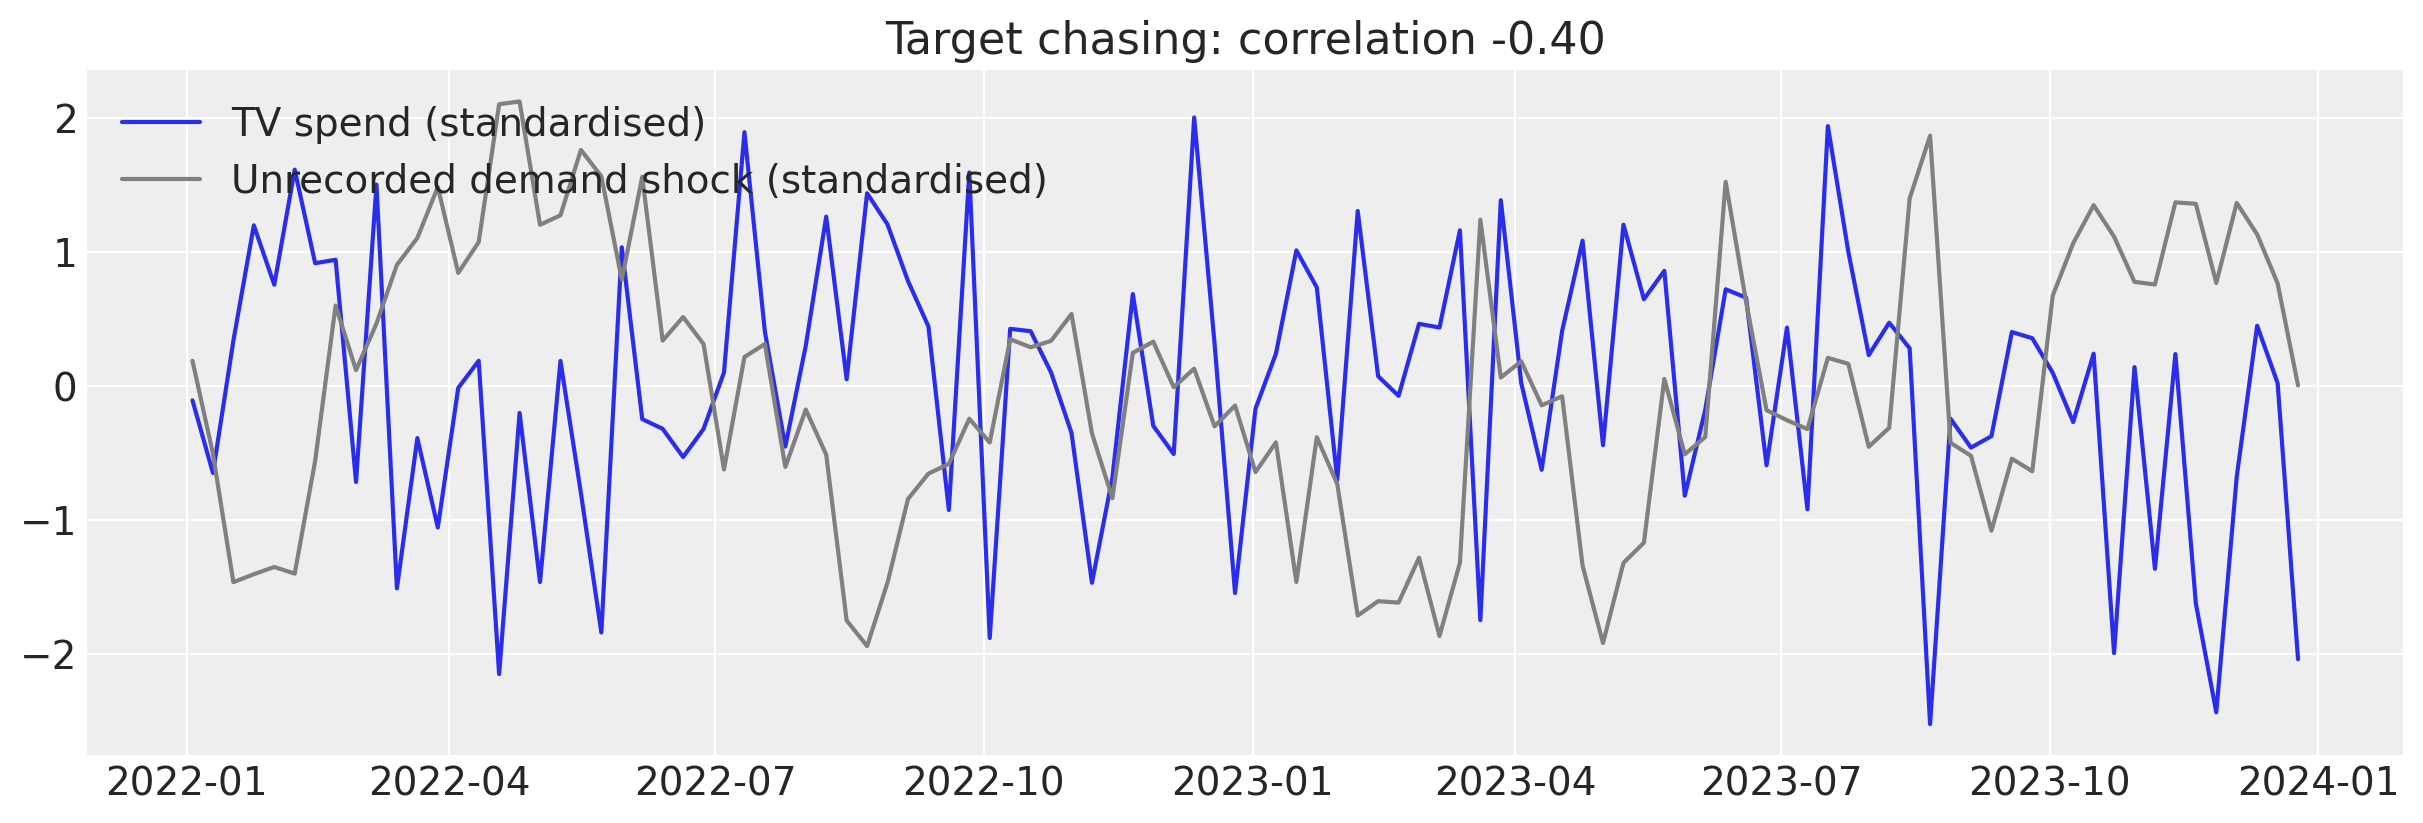

In [5]:
target_market = simulate_endogenous_spend_market("target_chasing", random_seed=SEED)
plot_mechanism(target_market, "Target chasing");

NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_alpha, gamma_fourier, gamma_control, intercept_contribution, y_sigma]


Output()

NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_alpha, gamma_fourier, gamma_control, intercept_contribution, y_sigma]


Output()

NUTS[nutpie]: [budget_gamma_lag, budget_spend_fourier_coef, budget_spend_control_coef, budget_spend_intercept, budget_gamma, gamma_fourier, gamma_control, adstock_alpha, saturation_lam, saturation_alpha, intercept_contribution, y_sigma, budget_spend_sigma]


Output()

,mean,3%,97%,divergences,truth
Plain MMM,0.80,0.09,1.69,0.0,1.95
Plain MMM + lift likelihood,1.08,0.37,1.87,0.0,1.95
Budget model + design,1.99,0.38,3.58,8.0,1.95


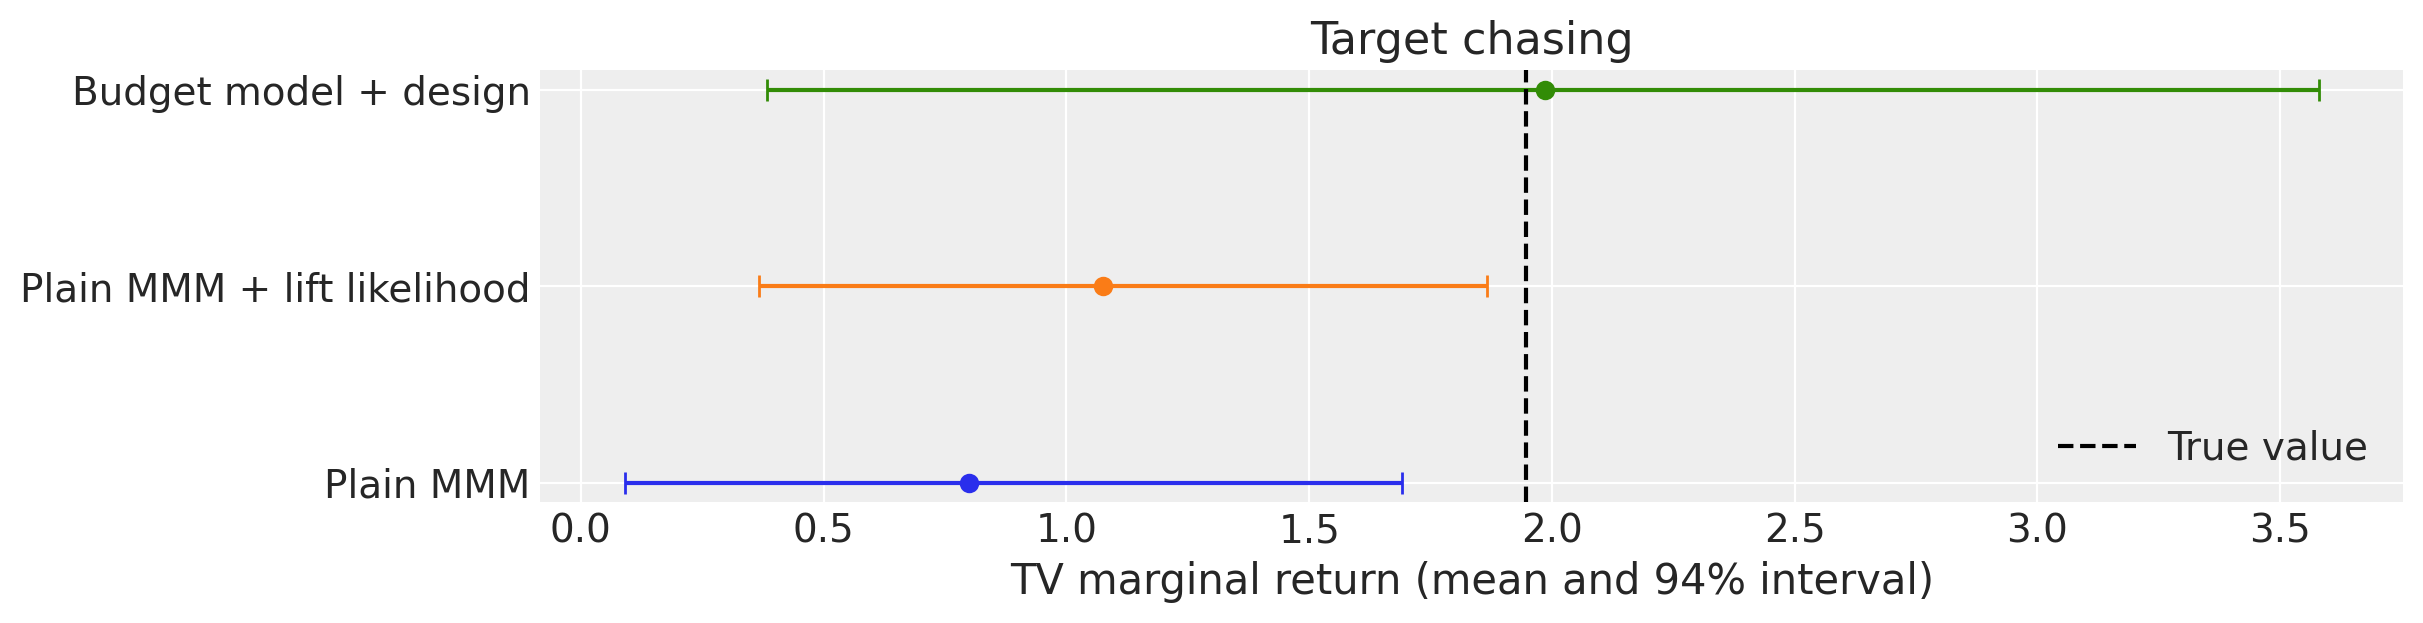

In [6]:
target_table, target_draws, target_gamma = fit_market(target_market)
plot_intervals(target_draws, target_market.true_marginal_return, "Target chasing")
target_table.round(2)

In [7]:
target_gamma.round(3)

,channel,lag,gamma_mean,gamma_lower,gamma_upper,gamma_per_spend_unit,prob_positive,prior_sd,posterior_sd,contraction,identified_by_design,note
0,tv,0,-0.075,-0.174,0.015,-1.319,0.065,0.5,0.051,0.897,True,
1,digital,0,-0.096,-0.394,0.097,-2.566,0.344,0.5,0.152,0.696,False,no lift-test design: gamma rests on functional...
2,tv,1,-0.018,-0.072,0.033,-0.311,0.269,0.5,0.029,0.943,True,
3,digital,1,0.015,-0.037,0.061,0.398,0.724,0.5,0.026,0.947,False,no lift-test design: gamma rests on functional...


The plain MMM understates TV, as expected when spend runs against demand, and its interval excludes the truth. The lift likelihood moves the estimate up only a little, because the history keeps pulling the other way. The budget model lands almost exactly on the truth (1.99 against 1.95), with a wide interval: one four-week test of a feedback-driven budget does not pin the curve down tightly.

The control-function coefficient has the right sign. The posterior probability that the contemporaneous $\gamma_{TV}$ is negative is about 0.94, although its 94% interval just reaches zero, and the lagged coefficient is close to zero, so the evidence for countercyclical spending in this market is moderate rather than decisive.

## Scenario 2: Spend That Follows Search Demand

In paid search and other auction channels, nobody decides to chase demand. Spend is query volume times cost per click, and query volume rises with demand, until the weekly budget cap binds:

$$
\text{TV}_t = \min\left(\text{cap},\; 5\, e^{0.12\, d_t} \cdot \text{CPC}_t\right).
$$

(The channel keeps the name `tv` so all scenarios share one model specification.) The endogeneity is contemporaneous and strong. The cap also makes it nonlinear: once the cap binds, spend stops moving while demand keeps moving, which a linear control function cannot fully capture.

Search teams commonly test with holdouts, switching the channel off for a few weeks. That is a `mode="set"` design: spend in those weeks is fixed by the experiment, carries no demand information, and is masked out of the budget model rather than shifted.

,channel,start_date,end_date,mode,delta_x
0,tv,2024-01-01,2024-01-22,set,NaN


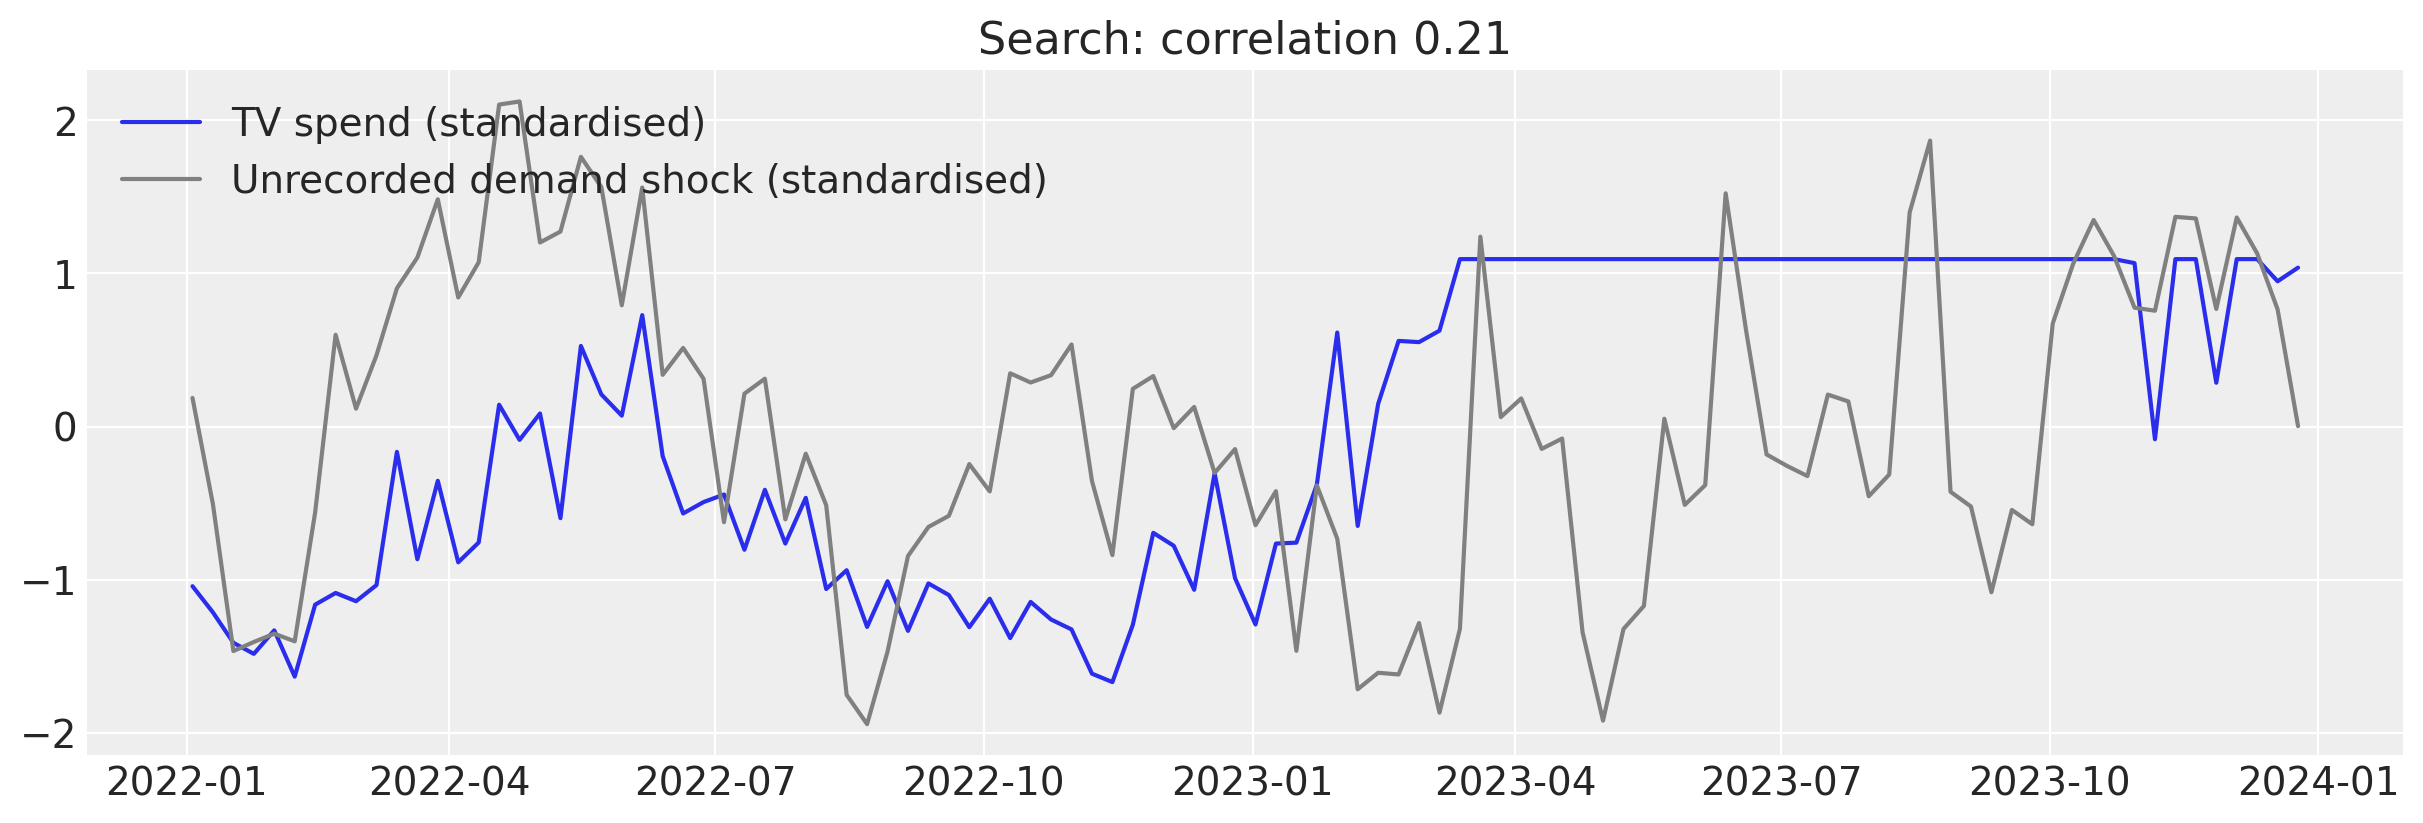

In [8]:
search_market = simulate_endogenous_spend_market("search", random_seed=SEED)
plot_mechanism(search_market, "Search")
search_market.design

NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_alpha, gamma_fourier, gamma_control, intercept_contribution, y_sigma]


Output()

NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_alpha, gamma_fourier, gamma_control, intercept_contribution, y_sigma]


Output()

NUTS[nutpie]: [budget_gamma_lag, budget_spend_fourier_coef, budget_spend_control_coef, budget_spend_intercept, budget_gamma, gamma_fourier, gamma_control, adstock_alpha, saturation_lam, saturation_alpha, intercept_contribution, y_sigma, budget_spend_sigma]


Output()

,mean,3%,97%,divergences,truth
Plain MMM,2.97,2.49,3.42,0.0,1.96
Plain MMM + lift likelihood,2.70,2.30,3.06,0.0,1.96
Budget model + design,2.43,1.17,3.27,2.0,1.96


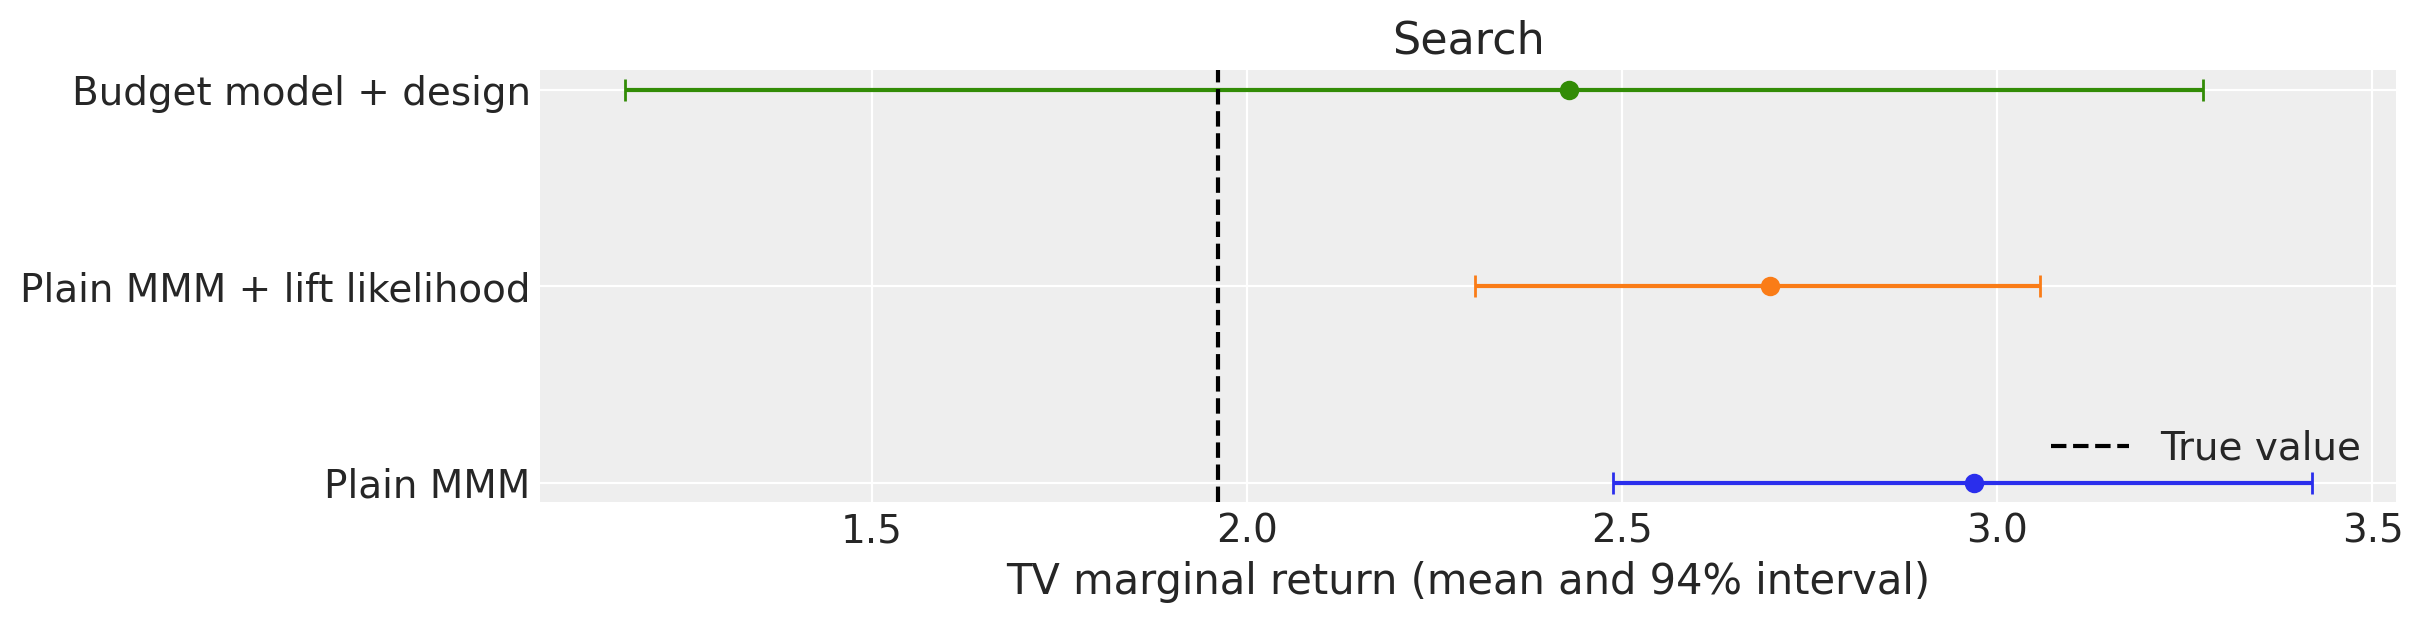

In [9]:
search_table, search_draws, search_gamma = fit_market(search_market)
plot_intervals(search_draws, search_market.true_marginal_return, "Search")
search_table.round(2)

In [10]:
search_gamma.round(3)

,channel,lag,gamma_mean,gamma_lower,gamma_upper,gamma_per_spend_unit,prob_positive,prior_sd,posterior_sd,contraction,identified_by_design,note
0,tv,0,0.062,-0.004,0.143,1.004,0.960,0.5,0.039,0.922,True,
1,digital,0,-0.136,-0.393,0.068,-3.709,0.165,0.5,0.131,0.739,False,no lift-test design: gamma rests on functional...
2,tv,1,-0.015,-0.065,0.032,-0.242,0.293,0.5,0.026,0.948,True,
3,digital,1,0.017,-0.028,0.058,0.475,0.779,0.5,0.023,0.953,False,no lift-test design: gamma rests on functional...


Both plain fits overstate TV and are confident about it; neither interval covers the truth. With the holdout design, the budget model moves towards the truth and its interval covers it, and $\gamma_{TV}$ is positive with probability about 0.96.

Its posterior mean still sits above the truth. That is consistent with a linear control function that cannot fully absorb a capped relationship between demand and spend. For channels whose budgets bind, treat the corrected estimate as an improvement rather than a fix.

## Scenario 3: Spend That Follows Only Recorded Drivers

Here budgets respond strongly to seasonality, inflation and unemployment, all of which the MMM controls for, and not at all to the unrecorded shock:

$$
\text{TV}_t = 5 + 0.25\,(\text{predictable demand})_t + \text{noise}_t .
$$

Spend and sales are strongly correlated, but the controls close the backdoor path, so a plain MMM is unbiased. This is the negative control: it asks whether the budget model raises a false alarm, and what the correction costs when there is nothing to correct.

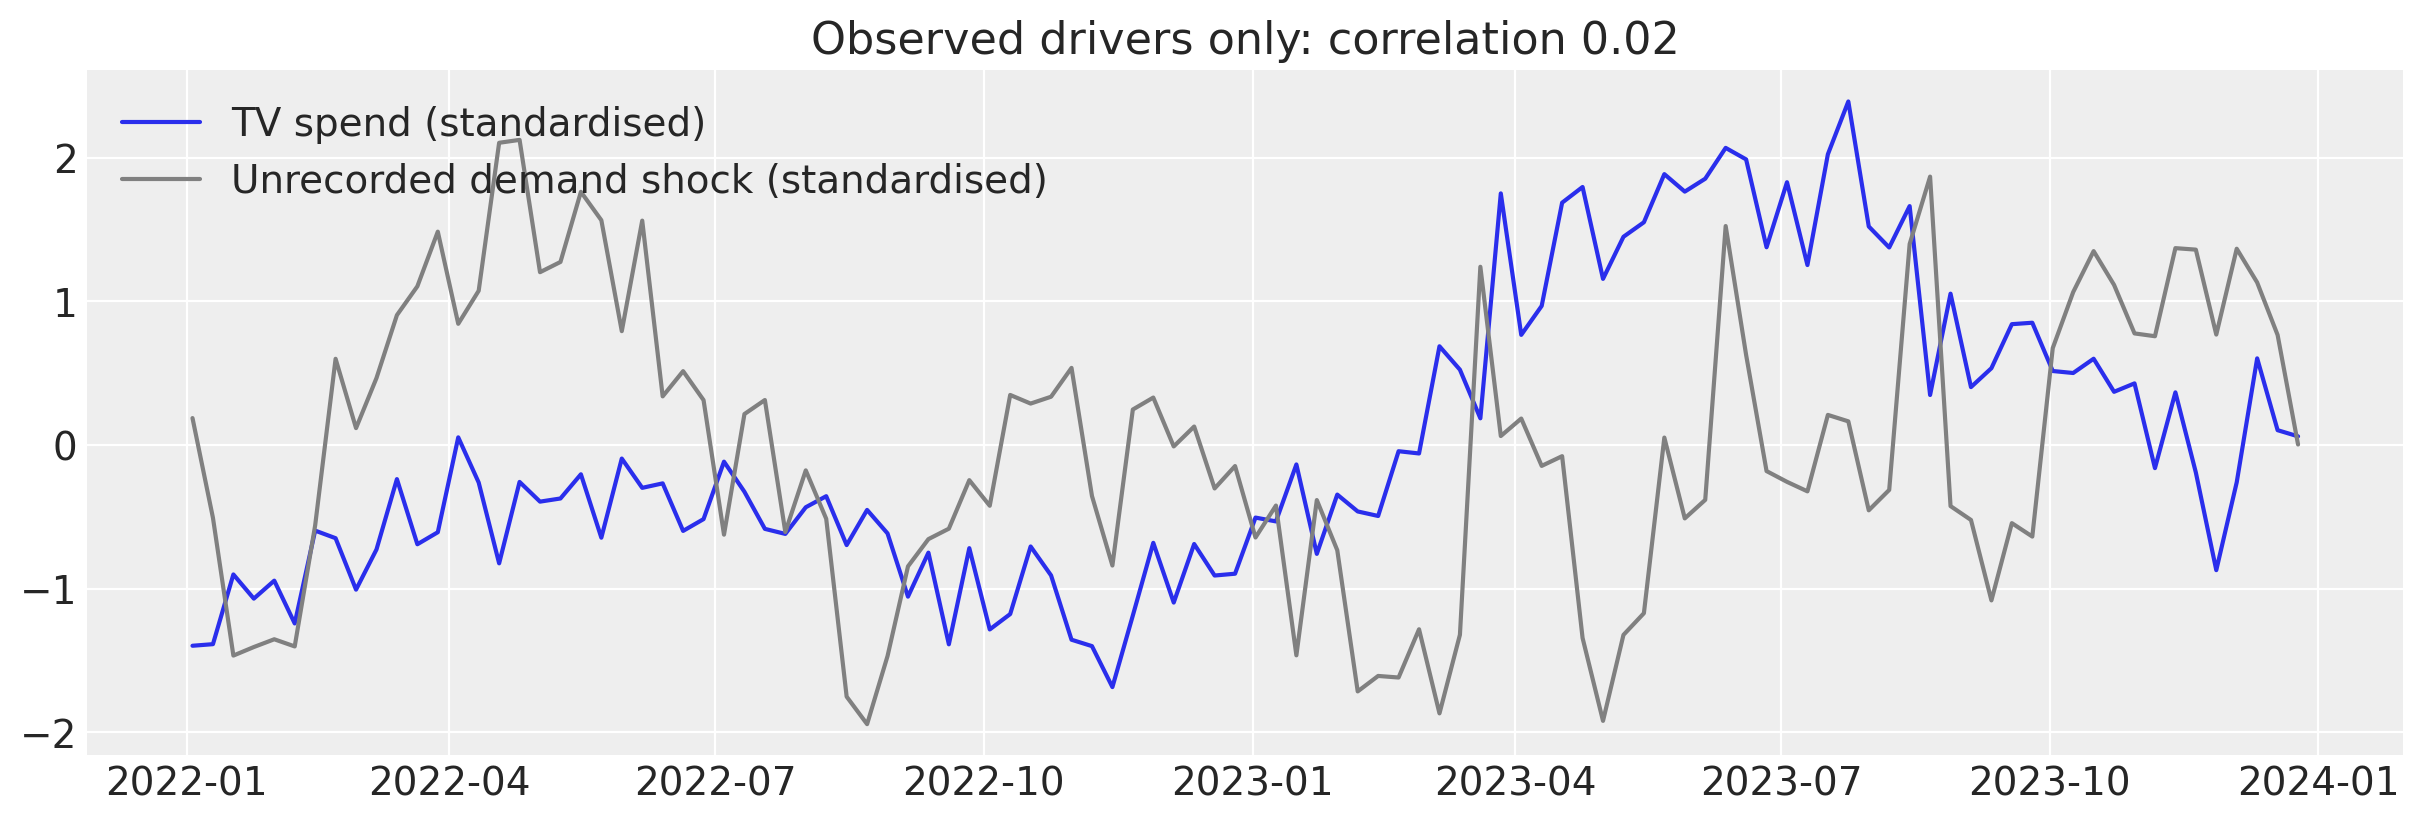

In [11]:
observed_market = simulate_endogenous_spend_market("observed_only", random_seed=SEED)
plot_mechanism(observed_market, "Observed drivers only");

NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_alpha, gamma_fourier, gamma_control, intercept_contribution, y_sigma]


Output()

NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_alpha, gamma_fourier, gamma_control, intercept_contribution, y_sigma]


Output()

NUTS[nutpie]: [budget_gamma_lag, budget_spend_fourier_coef, budget_spend_control_coef, budget_spend_intercept, budget_gamma, gamma_fourier, gamma_control, adstock_alpha, saturation_lam, saturation_alpha, intercept_contribution, y_sigma, budget_spend_sigma]


Output()

,mean,3%,97%,divergences,truth
Plain MMM,2.12,1.08,3.30,0.0,1.94
Plain MMM + lift likelihood,1.60,0.84,2.31,0.0,1.94
Budget model + design,2.64,1.10,4.45,0.0,1.94


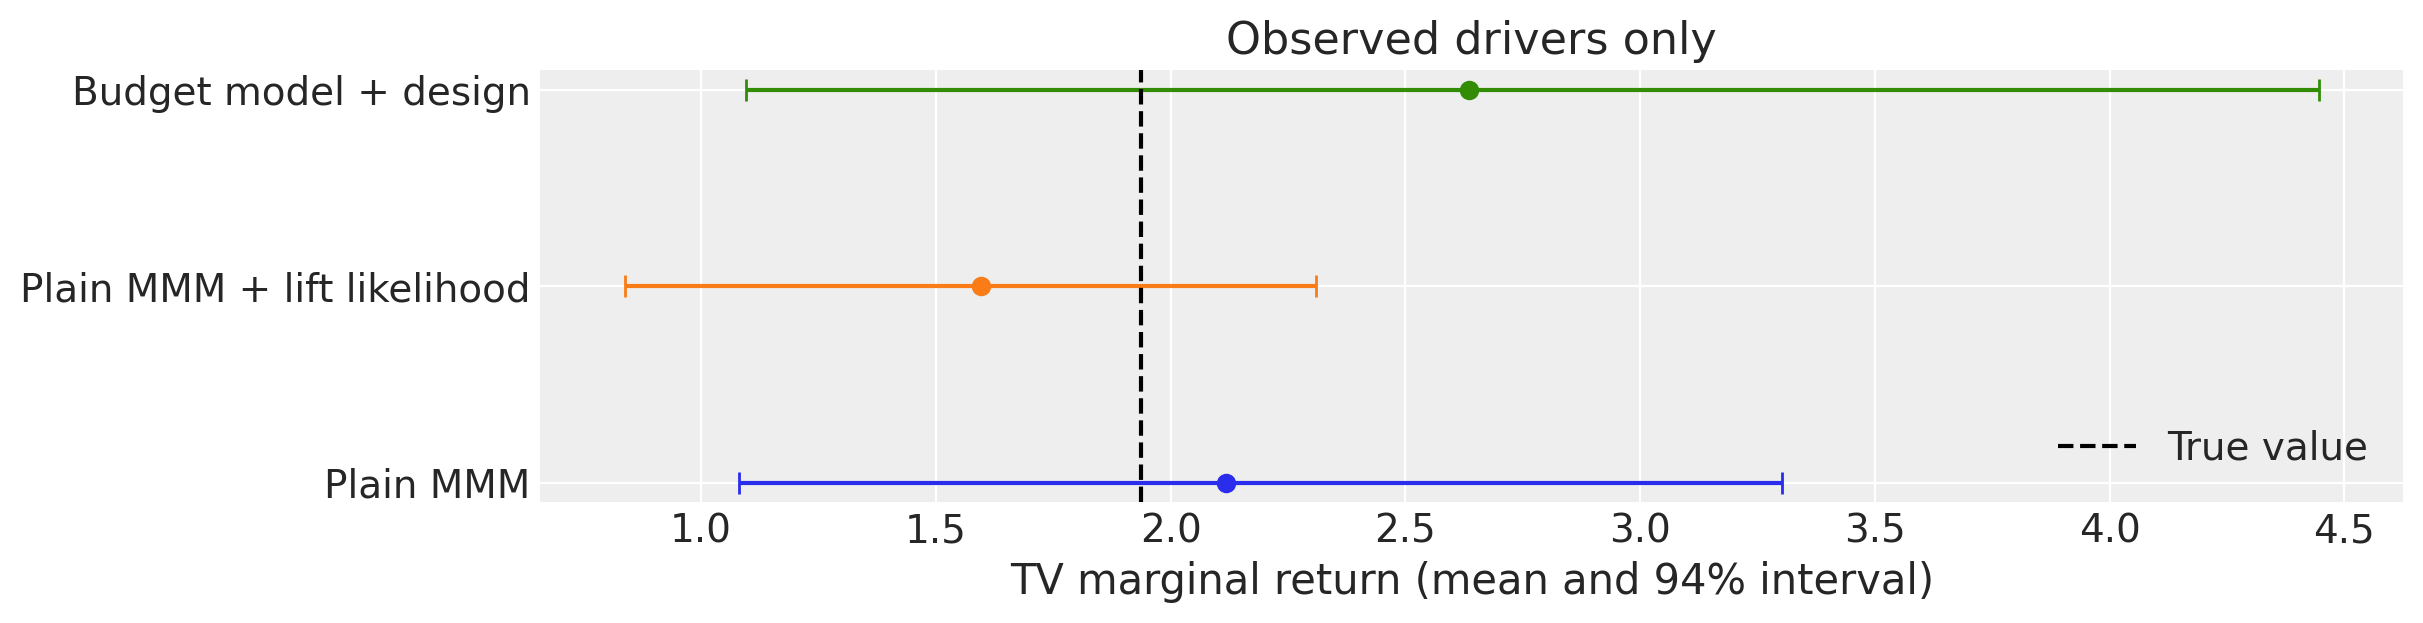

In [12]:
observed_table, observed_draws, observed_gamma = fit_market(observed_market)
plot_intervals(
    observed_draws, observed_market.true_marginal_return, "Observed drivers only"
)
observed_table.round(2)

In [13]:
observed_gamma.round(3)

,channel,lag,gamma_mean,gamma_lower,gamma_upper,gamma_per_spend_unit,prob_positive,prior_sd,posterior_sd,contraction,identified_by_design,note
0,tv,0,-0.075,-0.215,0.071,-1.061,0.145,0.5,0.074,0.853,True,
1,digital,0,-0.069,-0.314,0.086,-1.903,0.337,0.5,0.116,0.768,False,no lift-test design: gamma rests on functional...
2,tv,1,0.023,-0.084,0.126,0.329,0.658,0.5,0.056,0.887,True,
3,digital,1,0.031,-0.017,0.072,0.846,0.897,0.5,0.024,0.952,False,no lift-test design: gamma rests on functional...


There is no false alarm: the plain MMM and the lift likelihood both cover the truth, and the interval for $\gamma_{TV}$ includes zero. The correction is not free, though. The budget model's estimate moves away from the truth (2.64 against 1.94, where the plain MMM gave 2.12) and its interval is wider, and $\gamma_{TV}$ leans negative (probability about 0.86 below zero).

When there is little to correct, the control-function terms and the slope of the response curve are both close to linear in recent spend, so they trade off against each other and the design does not fully separate them. Digital shows the same tendency in all three markets: it is exogenous in every scenario and never tested, yet its contemporaneous $\gamma$ leans negative each time, and its lagged coefficient leans positive. A $\gamma$ for a channel without designed variation reflects the priors as much as the data, which is why {meth}`~pymc_marketing.mmm.budget_model.BudgetModelEffect.exogeneity_summary` flags it.

## Summary

- **Endogenous spend is not one mechanism.** Budgets that follow a forecast, budgets that chase targets, and spend that follows demand mechanically all bias a plain MMM, and not always in the same direction. In the two endogenous markets here, a lift likelihood narrowed the estimate without removing the bias.
- **With an experiment's design and one lagged surprise, the budget model covered TV's true marginal return in both endogenous markets.** The price is wider intervals, which reflect what one short test can actually pin down. Single markets overstate how often that happens: over 50 markets in the forecast scenario of {ref}`mmm_endogenous_budget`, the intervals undercover by about ten points, covering the truth in 82% of markets against a nominal 94% (see the table in `scripts/budget_model/simulation_study.py`).
- **When the controls already close the backdoor, the correction costs accuracy.** In the negative control the budget model moved away from the truth (2.64 against 1.94, where the plain MMM gave 2.12), with a wider interval.
- **In a single market, $\gamma$ alone does not separate these cases.** Its sign followed the mechanism (negative for target chasing, positive for search), but the negative control's $\gamma_{TV}$ (probability 0.86 below zero) is nearly as strong as target chasing's (0.94), and none of the three 94% intervals excludes zero. Read $\gamma$ as a diagnostic that accumulates evidence across experiments and markets, not as a verdict from one fit.

In practice: if budgets in your business plausibly follow demand in any of these ways, fit the budget model with your experiments' designs alongside the plain MMM, and compare the two. A tested channel whose $\gamma$ interval clearly excludes zero is evidence that the plain MMM's attribution for it is biased; a leaning $\gamma$ is not, because the correction can lean even when nothing needs correcting. Treat $\gamma$ for untested channels as prior-sensitive, and put recorded demand proxies in the MMM's `control_columns`, never in the budget model's `instruments`.

In [14]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,pytensor

Last updated: Tue, 29 Sep 2026

Python implementation: CPython
Python version       : 3.14.6
IPython version      : 9.15.0

pymc_marketing: 1.0.0.dev0
pytensor      : 3.0.7

matplotlib    : 3.10.9
numpy         : 2.4.6
pandas        : 2.3.3
pymc_marketing: 1.0.0.dev0

Watermark: 2.6.0

